# <h1><center id="policy-top">Оценка бизнес-ценности политик коммуникации</center></h1>

### Оглавление
* <a href="#policy-imports">0. Импорты и настройки</a>
* <a href="#policy-load">1. Загрузка предсказанных скоров</a>
* <a href="#policy-economics">2. Экономическая постановка</a>
* <a href="#policy-strategies">3. Стратегии коммуникации</a>
* <a href="#policy-budget-curves">4. Сценарные бюджетные кривые</a>
* <a href="#policy-fixed-coverage">5. Фиксированный охват в сценариях</a>
* <a href="#policy-roi">6. ROI в сценариях</a>
* <a href="#policy-multitreatment">7. Multi-treatment policy</a>
* <a href="#policy-segments">8. Сегментация клиентов</a>
* <a href="#policy-bootstrap">9. Bootstrap-интервалы</a>
* <a href="#policy-conclusions">10. Практические рекомендации</a>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Роль ноутбука.</b> Этот финальный слой переводит модельные скоры в бизнес-решения: кого контактировать, каким каналом, при каком бюджете и какой чистый эффект можно ожидать.

</div>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Как читать результаты.</b> Метрики качества моделей здесь становятся управленческими показателями: предотвращенные дефолты, стоимость контактов, ROI, сегменты клиентов и доверительные интервалы.

</div>

<div class="alert alert-warning" style="background-color:#fff8e6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Ограничение.</b> Экономические параметры сценарные. Они показывают метод расчета, но перед внедрением должны быть заменены на реальные стоимости каналов, LGD/PD-экономику и операционные ограничения банка.

</div>

<h2 id="policy-imports">0. Импорты и настройки</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Подключаем библиотеки, задаем оформление графиков и фиксируем общие настройки. Этот раздел технический, но он нужен, чтобы все последующие таблицы и графики строились одинаково при повторном запуске.

</div>


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

RANDOM_SEED = 91
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.options.display.float_format = '{:.4f}'.format


<h2 id="policy-load">1. Загрузка предсказанных скоров</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Загружаем файл с оценками моделей, который был сохранен в ноутбуке с uplift-моделями. Здесь уже есть скоринги риск-моделей, мета-алгоритмов и оракульные ориентиры.

Дальше эти скоринги используются как готовые правила ранжирования клиентов. Мы не меняем сами модели, а проверяем, какую бизнес-ценность дали бы их рекомендации.

</div>


In [2]:
import os

SCORES_PATH = 'data/processed/uplift_scores.csv'

if not os.path.exists(SCORES_PATH):
    raise FileNotFoundError(
        'Файл uplift_scores.csv не найден. Запустите uplift_models.ipynb до конца.'
    )

df_scores = pd.read_csv(SCORES_PATH)
print(f'Загружено: {len(df_scores):,} строк x {df_scores.shape[1]} колонок')
print(f'test: {(df_scores.split == "test").sum():,}  |  OOT: {(df_scores.split == "oot").sum():,}')
print(f'Доля дефолтов: {df_scores.y.mean():.3%}')
print(f'Колонки: {list(df_scores.columns)}')


Загружено: 123,005 строк x 21 колонок
test: 61,502  |  OOT: 61,503
Доля дефолтов: 7.670%
Колонки: ['split', 'y', 'treatment_bin', 'COMMUNICATION', 'BASE_PD', 'TRUE_UPLIFT', 'RISK_SEGMENT', 'score_cb_saved', 'score_cb_all', 'score_lr_saved', 'score_lr_all', 'score_s', 'score_t', 'score_x', 'score_dr', 'uplift_s_sms', 'uplift_s_robot', 'uplift_s_operator', 'uplift_t_sms', 'uplift_t_robot', 'uplift_t_operator']


In [3]:
# Разделяем на test и OOT для последующего анализа
df_test = df_scores[df_scores.split == 'test'].reset_index(drop=True)
df_oot  = df_scores[df_scores.split == 'oot'].reset_index(drop=True)

print(f'test: {len(df_test):,} клиентов | OOT: {len(df_oot):,} клиентов')


test: 61,502 клиентов | OOT: 61,503 клиентов


<h2 id="policy-economics">2. Экономическая постановка задачи</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем нужна экономическая постановка.</b> В предыдущем ноутбуке модели сравнивались по качеству ранжирования: Qini, AUUC, bootstrap и связь с `TRUE_UPLIFT`. Но для бизнес-решения этого недостаточно. Банку важно понять не только какая стратегия лучше сортирует клиентов, но и сколько денег она может принести при заданном бюджете, стоимости каналов и ценности предотвращенного дефолта.

<p><b>Как устроена модель ценности.</b></p>

В этом разделе задается простая сценарная экономика коммуникационной кампании:

<ul>
  <li>каждый контакт имеет стоимость: `sms`, `robot_call` и `operator_call` стоят по-разному;</li>
  <li>предотвращенный дефолт имеет денежную ценность, заданную через `LOSS_GIVEN_DEFAULT`;</li>
  <li>полезность коммуникации считается через снижение вероятности дефолта: если `TRUE_UPLIFT < 0`, контакт уменьшает PD;</li>
  <li>экономический эффект стратегии равен ожидаемой выгоде от предотвращенных дефолтов минус затраты на коммуникации.</li>
</ul>

<p><b>Как читать стоимость каналов.</b></p>

Параметры стоимости являются сценарными, а не банковскими тарифами: `sms = 5 руб.`, `robot_call = 30 руб.`, `operator_call = 200 руб.`. Для стратегий с единым охватом также используется усредненная стоимость контакта `COST_ANY_CONTACT = 80 руб.`. Это нужно, чтобы сравнивать политики в одном масштабе и показать принцип расчета.

<p><b>Как читать ценность предотвращенного дефолта.</b></p>

`LOSS_GIVEN_DEFAULT = 240 000 руб.` задает условную денежную ценность одного предотвращенного дефолта. Если стратегия снижает суммарную вероятность дефолта на 1.0, это интерпретируется как один ожидаемый предотвращенный дефолт, умноженный на LGD.

<p><b>Граница интерпретации.</b></p>

Эти параметры не претендуют на точную экономику конкретного банка. Их задача — показать методику: как перейти от модельного uplift-скора к расчету бюджета, ожидаемого эффекта, ROI и оптимального выбора канала. Перед реальным внедрением значения стоимостей, LGD, лимитов контактов и операционных ограничений должны быть заменены на фактические бизнес-параметры.

</div>

In [4]:
# Параметры экономической модели
COMM_COSTS = {
    'control':      0,
    'sms':          5,
    'robot_call':   30,
    'operator_call': 200,
}

# Средняя стоимость коммуникации (при смешанном составе treatment в данных)
COST_ANY_CONTACT = 80   # средневзвешенная по составу treatment-групп

LOSS_GIVEN_DEFAULT = 240_000   # руб.

print('Экономические параметры:')
for ch, cost in COMM_COSTS.items():
    if ch != 'control':
        print(f'  {ch:<20} стоимость={cost:>5} руб.')
print(f'  LGD (ценность предотвращённого дефолта): {LOSS_GIVEN_DEFAULT:,} руб.')

# Вычисляем предотвращённый дефолт по истинному uplift
# TRUE_UPLIFT < 0 означает снижение PD, поэтому берём -TRUE_UPLIFT
df_test['prevented_default_prob'] = -df_test['TRUE_UPLIFT']   # снижение вероятности дефолта
df_oot['prevented_default_prob']  = -df_oot['TRUE_UPLIFT']

print(f'\nРаспределение TRUE_UPLIFT (test):')
print(df_test['TRUE_UPLIFT'].describe().round(5))


Экономические параметры:
  sms                  стоимость=    5 руб.
  robot_call           стоимость=   30 руб.
  operator_call        стоимость=  200 руб.
  LGD (ценность предотвращённого дефолта): 240,000 руб.

Распределение TRUE_UPLIFT (test):
count   61502.0000
mean       -0.0024
std         0.0111
min        -0.3295
25%         0.0000
50%         0.0000
75%         0.0000
max         0.0333
Name: TRUE_UPLIFT, dtype: float64


<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Как читать экономические параметры.</b> Стоимость канала и ценность предотвращенного дефолта задают сценарий. При изменении этих параметров ранжирование моделей может остаться прежним, а оптимальный охват и ROI изменятся.

</div>


<h2 id="policy-strategies">3. Стратегии коммуникации</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем задаем набор стратегий.</b> Дальше сравниваются не сами модели как алгоритмы, а коммуникационные политики: кого поставить выше в списке на контакт при ограниченном бюджете. Одна и та же модельная оценка становится правилом отбора клиентов, а качество стратегии измеряется через предотвращенные дефолты, экономический эффект и ROI.

<p><b>Какие политики сравниваются.</b></p>

<ul>
  <li><b>Никого не контактировать</b> — нулевая политика, нужна как базовая точка отсчета без затрат и без эффекта.</li>
  <li><b>Случайный выбор</b> — показывает, что дает кампания без интеллектуального ранжирования.</li>
  <li><b>Risk-based (`BASE_PD`)</b> — идеализированный риск-ориентир синтетического стенда. Это не production-модель, а верхняя оценка того, насколько сильной может быть логика отбора только по базовому риску.</li>
  <li><b>CatBoost-risk</b> — главный реалистичный risk-based baseline: сильная модель риска, обученная на `TARGET` и всех доступных признаках.</li>
  <li><b>LogReg-risk</b> — интерпретируемый банковский baseline: логистическая регрессия на `TARGET` и всех доступных признаках.</li>
  <li><b>S-Learner</b> и <b>T-Learner</b> — основные uplift-стратегии, которые используют оценки индивидуального эффекта коммуникации.</li>
  <li><b>X-Learner</b> и <b>DR-Learner</b> — дополнительные causal-подходы, которые сохраняются для расширенной диагностики, но не являются фокусом основных графиков.</li>
  <li><b>Oracle</b> — недостижимая верхняя граница, построенная по известному `TRUE_UPLIFT` синтетического стенда.</li>
</ul>

<p><b>Почему разделяем `BASE_PD` и обученные risk-модели.</b></p>

`BASE_PD` полезен методологически: он показывает, насколько риск может имитировать uplift, если риск и эффект коммуникации структурно связаны. Но для практического сравнения с uplift важнее CatBoost-risk и LogReg-risk: это модели, которые действительно обучаются на данных и ближе к production-сценарию.

<p><b>Главный вопрос раздела.</b></p>

Сравнение должно показать, дает ли uplift-ранжирование дополнительную бизнес-ценность не только относительно случайного выбора и oracle, но и относительно сильных реалистичных риск-моделей.

</div>

In [5]:
# Определяем скоры для каждой стратегии
# Знак: выше скор = приоритетнее для контакта
rng = np.random.RandomState(RANDOM_SEED)

strategies = {
    'Никого не контактировать': np.zeros(len(df_test)),
    'Случайный выбор':           rng.rand(len(df_test)),
    'Risk-based (BASE_PD)':      df_test['BASE_PD'].values,
    'CatBoost-risk (all feat)':  df_test['score_cb_all'].values,
    'LogReg-risk (all feat)':    df_test['score_lr_all'].values,
    'S-Learner':                 df_test['score_s'].values,
    'T-Learner':                 df_test['score_t'].values,
    'X-Learner':                 df_test['score_x'].values,
    'DR-Learner':                df_test['score_dr'].values,
    'Oracle':                   -df_test['TRUE_UPLIFT'].values,
}

# Основной набор стратегий для читаемых policy-графиков и таблиц.
main_policy_strategies = [
    'Случайный выбор',
    'Risk-based (BASE_PD)',
    'CatBoost-risk (all feat)',
    'LogReg-risk (all feat)',
    'S-Learner',
    'T-Learner',
    'Oracle',
]

# Цвета для визуализации
strategy_colors = {
    'Никого не контактировать': 'lightgray',
    'Случайный выбор':          'silver',
    'Risk-based (BASE_PD)':     'dimgray',
    'CatBoost-risk (all feat)': 'saddlebrown',
    'LogReg-risk (all feat)':   'steelblue',
    'S-Learner':                'royalblue',
    'T-Learner':                'darkorange',
    'X-Learner':                'green',
    'DR-Learner':               'crimson',
    'Oracle':                   'black',
}
strategy_styles = {
    'Никого не контактировать': ':',
    'Случайный выбор':          ':',
    'Risk-based (BASE_PD)':     '--',
    'CatBoost-risk (all feat)': '-.',
    'LogReg-risk (all feat)':   ':',
    'S-Learner':  '-',
    'T-Learner':  '-',
    'X-Learner':  '-',
    'DR-Learner': '-',
    'Oracle':     '--',
}

print('Стратегии определены:', list(strategies.keys()))
print('Основной набор для сравнения:', main_policy_strategies)

Стратегии определены: ['Никого не контактировать', 'Случайный выбор', 'Risk-based (BASE_PD)', 'CatBoost-risk (all feat)', 'LogReg-risk (all feat)', 'S-Learner', 'T-Learner', 'X-Learner', 'DR-Learner', 'Oracle']
Основной набор для сравнения: ['Случайный выбор', 'Risk-based (BASE_PD)', 'CatBoost-risk (all feat)', 'LogReg-risk (all feat)', 'S-Learner', 'T-Learner', 'Oracle']


<h2 id="policy-budget-curves">4. Сценарные кривые «бюджет — предотвращенные дефолты»</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем добавляем сценарии в экономическую оценку.</b> В базовом сценарии риск и эффект коммуникации связаны, поэтому risk-based стратегия может выглядеть почти оптимальной. Это один из ключевых барьеров внедрения uplift в финтехе: привычный скоринг риска часто уже дает сильный бизнес-результат, а дополнительная сложность uplift-моделей требует отдельного обоснования.

<p><b>Что меняем в сценариях.</b></p>

Как и в ноутбуке с uplift-моделями, дальше рассматриваются четыре варианта связи между `BASE_PD` и `TRUE_UPLIFT`: `aligned`, `weakly_aligned`, `orthogonal` и `mid_risk`. Клиенты, их признаки, сохраненные модельные скоры и стоимость коммуникации остаются неизменными. Меняется только ground truth полезности контакта, то есть то, у каких клиентов коммуникация действительно снижает вероятность дефолта.

<p><b>Что именно сравниваем.</b></p>

На этом этапе мы оцениваем уже готовые политики отбора: идеализированный `BASE_PD`, реалистичные CatBoost/LogReg risk-baseline, S-Learner, T-Learner и Oracle. Это не переобучение моделей, а стресс-тест policy-слоя: насколько финансовая ценность сохраненных правил отбора зависит от предположения о связи риска и эффекта.

<p><b>Как читать результат.</b></p>

Если `BASE_PD` остается сильным при всех сценариях, значит риск является устойчивым proxy для полезности коммуникации. Если же S/T-Learner превосходят CatBoost-risk или LogReg-risk, это уже более практический аргумент в пользу uplift. Если ее преимущество сужается при ослаблении связи риска и эффекта, это показывает, где uplift-подход становится методологически необходимым: там, где нужно искать изменяемый сегмент, а не просто верх risk-рейтинга.

</div>

In [6]:
# ====== Сценарии связи риска и эффекта для policy evaluation ======
_scenario_labels = {
    'aligned':        'Согласованный',
    'weakly_aligned': 'Слабо согласованный',
    'orthogonal':     'Независимый',
    'mid_risk':       'Средний риск',
}

_scenario_explain = {
    'aligned':        'исходная связь риска и эффекта',
    'weakly_aligned': 'частично ослабленная связь',
    'orthogonal':     'эффект перемешан внутри канала',
    'mid_risk':       'максимальный эффект около среднего риска',
}


def _sw_aligned(df, **kw):
    """Исходный DGP: TRUE_UPLIFT без изменений."""
    return df['TRUE_UPLIFT'].values.copy()


def _sw_weakly(df, alpha=0.5, seed=RANDOM_SEED + 201, **kw):
    """50% исходного эффекта + 50% перемешанного эффекта внутри канала."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        idx = np.where(mask)[0]
        perm = rng_s.permutation(len(idx))
        tu[idx] = alpha * tu[idx] + (1 - alpha) * tu[idx][perm]
    return tu


def _sw_orthogonal(df, seed=RANDOM_SEED + 202, **kw):
    """Эффект перемешивается внутри каждого канала коммуникации."""
    rng_s = np.random.RandomState(seed)
    tu = df['TRUE_UPLIFT'].values.copy()
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 2:
            continue
        idx = np.where(mask)[0]
        perm = rng_s.permutation(len(idx))
        tu[idx] = tu[idx][perm]
    return tu


def _sw_mid_risk(df, **kw):
    """Самые сильные эффекты назначаются клиентам около медианного BASE_PD внутри канала."""
    tu = df['TRUE_UPLIFT'].values.copy()
    bp = df['BASE_PD'].values
    for ch in ['sms', 'robot_call', 'operator_call']:
        mask = (df['COMMUNICATION'] == ch).values
        if mask.sum() < 10:
            continue
        idx = np.where(mask)[0]
        eff_ch = tu[idx]
        bp_ch = bp[idx]

        eff_order = np.argsort(eff_ch)  # самые отрицательные эффекты первыми
        bp_med = np.median(bp_ch)
        client_order = np.argsort(np.abs(bp_ch - bp_med))

        new_eff = np.empty(len(idx))
        new_eff[client_order] = eff_ch[eff_order]
        tu[idx] = new_eff
    return tu


scenario_generators = {
    'aligned':        _sw_aligned,
    'weakly_aligned': _sw_weakly,
    'orthogonal':     _sw_orthogonal,
    'mid_risk':       _sw_mid_risk,
}


def make_scenario_frame(df, scenario_name):
    """Возвращает копию df с пересчитанной полезностью коммуникации для сценария."""
    df_sc = df.copy()
    scenario_uplift = scenario_generators[scenario_name](df_sc)
    df_sc['scenario_true_uplift'] = scenario_uplift
    df_sc['prevented_default_prob'] = -scenario_uplift
    return df_sc


def scenario_strategy_scores(df_sc, scenario_name):
    """Скоры стратегий для заданного сценария. Oracle строится по сценарному ground truth."""
    return {
        'Случайный выбор':          strategies['Случайный выбор'],
        'Risk-based (BASE_PD)':     df_sc['BASE_PD'].values,
        'CatBoost-risk (all feat)': df_sc['score_cb_all'].values,
        'LogReg-risk (all feat)':   df_sc['score_lr_all'].values,
        'S-Learner':                df_sc['score_s'].values,
        'T-Learner':                df_sc['score_t'].values,
        'X-Learner':                df_sc['score_x'].values,
        'DR-Learner':               df_sc['score_dr'].values,
        'Oracle':                   df_sc['prevented_default_prob'].values,
    }


def compute_budget_curve(df, score, n_points=200, cost_per_contact=COST_ANY_CONTACT):
    """Кривая: доля охвата, накопленное снижение PD, накопленная стоимость."""
    df_sorted = df.assign(score=score).sort_values('score', ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    step = max(1, n // n_points)

    fracs, prevented, costs = [0.0], [0.0], [0.0]
    for k in range(step, n + 1, step):
        top_k = df_sorted.iloc[:k]
        total_prevented = top_k['prevented_default_prob'].sum()
        total_cost = k * cost_per_contact
        fracs.append(k / n)
        prevented.append(total_prevented)
        costs.append(total_cost)
    return np.array(fracs), np.array(prevented), np.array(costs)


scenario_diag_rows = []
for sc_name, sc_fn in scenario_generators.items():
    df_sc = make_scenario_frame(df_test, sc_name)
    rho, _ = stats.spearmanr(df_sc['BASE_PD'], df_sc['prevented_default_prob'])
    scenario_diag_rows.append({
        'Сценарий': _scenario_labels[sc_name],
        'Описание': _scenario_explain[sc_name],
        'Spearman(BASE_PD, полезность)': rho,
        'Средняя полезность': df_sc['prevented_default_prob'].mean(),
    })

scenario_diag_df = pd.DataFrame(scenario_diag_rows)
display(scenario_diag_df.round({
    'Spearman(BASE_PD, полезность)': 4,
    'Средняя полезность': 5,
}))

,Сценарий,Описание,"Spearman(BASE_PD, полезность)",Средняя полезность
0,Согласованный,исходная связь риска и эффекта,0.2174,0.0024
1,Слабо согласованный,частично ослабленная связь,0.2139,0.0024
2,Независимый,эффект перемешан внутри канала,0.2108,0.0024
3,Средний риск,максимальный эффект около среднего риска,0.2027,0.0024


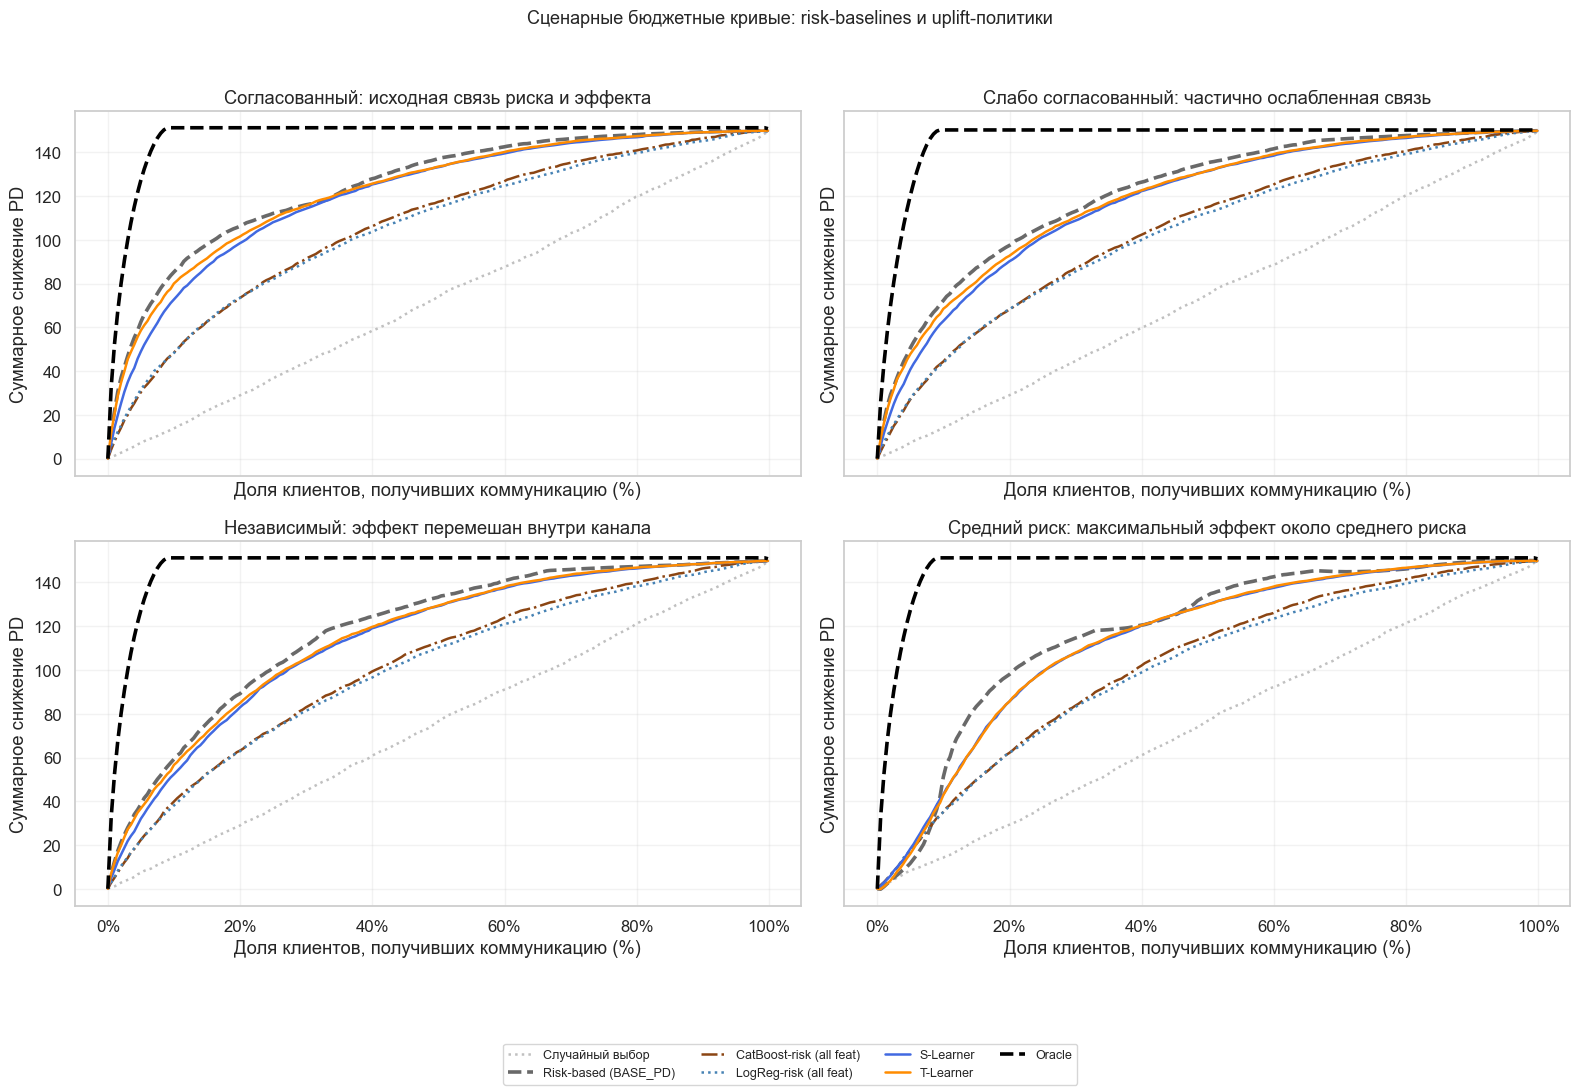

Как читать:
  - BASE_PD показывает идеализированную risk-based границу синтетического стенда.
  - CatBoost-risk и LogReg-risk — реалистичные конкуренты uplift-политик.
  - Разрыв S/T-Learner к CatBoost-risk показывает практическую ценность uplift-слоя.


In [7]:
plot_strategy_names = main_policy_strategies

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)
axes = axes.flatten()

scenario_budget_curves = {}
for ax, sc_name in zip(axes, scenario_generators.keys()):
    df_sc = make_scenario_frame(df_test, sc_name)
    sc_scores = scenario_strategy_scores(df_sc, sc_name)
    scenario_budget_curves[sc_name] = {}

    for name in plot_strategy_names:
        fracs, prevented, costs = compute_budget_curve(df_sc, sc_scores[name])
        scenario_budget_curves[sc_name][name] = (fracs, prevented, costs)
        lw = 2.6 if name in ('Oracle', 'Risk-based (BASE_PD)') else 1.8
        ax.plot(fracs * 100, prevented,
                label=name,
                color=strategy_colors[name],
                linestyle=strategy_styles[name],
                linewidth=lw)

    ax.set_title(f"{_scenario_labels[sc_name]}: {_scenario_explain[sc_name]}")
    ax.set_xlabel('Доля клиентов, получивших коммуникацию (%)')
    ax.set_ylabel('Суммарное снижение PD')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9)
plt.suptitle('Сценарные бюджетные кривые: risk-baselines и uplift-политики', fontsize=13)
plt.tight_layout(rect=[0, 0.10, 1, 0.96])
plt.show()

print('Как читать:')
print('  - BASE_PD показывает идеализированную risk-based границу синтетического стенда.')
print('  - CatBoost-risk и LogReg-risk — реалистичные конкуренты uplift-политик.')
print('  - Разрыв S/T-Learner к CatBoost-risk показывает практическую ценность uplift-слоя.')

<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Подпись к графикам.</b> Каждый график показывает один сценарий связи риска и полезности коммуникации. По оси X — доля клиентов, которых банк контактирует, по оси Y — суммарное ожидаемое снижение PD. Важнее всего левая часть графика: именно там видна ценность стратегии при ограниченном бюджете.

</div>

<h3 id="policy-budget-summary">Выводы по разделу 4</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по сценарным бюджетным кривым.</b>

<p><b>1. `BASE_PD` остается самым сильным risk-ориентиром, но это идеализированный baseline.</b></p>

На сценарных графиках `BASE_PD` почти всегда находится выше S/T-Learner. Это ожидаемо: `BASE_PD` встроен в синтетический механизм генерации и показывает, насколько сильной может быть стратегия отбора по риску, если риск связан с эффектом коммуникации. Поэтому `BASE_PD` важен методологически, но его нельзя трактовать как обычную production-модель.

<p><b>2. Практическое сравнение с CatBoost/LogReg меняет интерпретацию.</b></p>

Реалистичные risk-модели заметно слабее `BASE_PD`. При охвате 20% в сценарии `aligned` CatBoost-risk и LogReg-risk достигают около 48.6% и 48.5% от Oracle, тогда как S-Learner дает 65.1%, а T-Learner — 67.2%. В `mid_risk` CatBoost/LogReg находятся около 41%, а S/T-Learner — около 56.6–56.7%.

Это уже практический аргумент в пользу uplift: модели индивидуального эффекта дают прирост не над случайным выбором, а над реалистичными risk-based моделями.

<p><b>3. T-Learner чаще всего является лучшей доступной uplift-политикой.</b></p>

В большинстве сценариев T-Learner немного выше S-Learner: например, при 20% охвата в `aligned` T-Learner реализует 67.2% от Oracle против 65.1% у S-Learner; в `weakly_aligned` — 61.8% против 60.1%; в `orthogonal` — 56.3% против 54.8%. В `mid_risk` они практически равны.

<p><b>4. Сценарии показывают барьер и зону применимости uplift.</b></p>

Если сравнивать только с `BASE_PD`, uplift выглядит менее убедительно: идеализированный риск-скоринг остается очень сильным. Но если сравнивать с CatBoost/LogReg, uplift дает устойчивый прирост. Это хорошо отражает главный тезис работы: uplift сложно внедрять, потому что risk-based подходы часто сильны, но относительно реальных risk-моделей uplift может давать заметную дополнительную ценность.

<p><b>5. Практический вывод.</b></p>

Uplift стоит рассматривать как дополнительный слой поверх скоринга. Его задача — не победить синтетический `BASE_PD`, а улучшить решения относительно моделей, которые банк реально может обучить и внедрить: CatBoost, LogReg или другие risk-score модели.

<b>Итог.</b> После добавления CatBoost/LogReg вывод становится сильнее: uplift не превосходит идеализированный риск-ориентир `BASE_PD`, но заметно превосходит реалистичные risk-baseline по финансовому эффекту политики.

</div>

<h2 id="policy-fixed-coverage">5. Сравнение стратегий при фиксированном охвате в сценариях</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем фиксировать охват.</b> Бюджетные кривые дают общую форму результата, но бизнес обычно принимает решение в формате конкретного лимита кампании: контактировать 10%, 20% или 30% клиентов. Поэтому дальше сравниваются стратегии при одинаковом размере кампании, но в разных сценариях связи риска и эффекта.

<p><b>Что считается.</b></p>

Для каждой пары «сценарий — стратегия» клиенты сортируются по score, выбирается top-K и считаются: суммарное снижение PD, экономический эффект, затраты, ROI и процент от сценарного Oracle. В основной таблице показываются `BASE_PD`, CatBoost-risk, LogReg-risk, S-Learner, T-Learner, случайный выбор и Oracle. Так мы видим не только абсолютный финансовый эффект, но и насколько стратегия близка к теоретической верхней границе именно в этом сценарии.

<p><b>Почему это важно для аргументации uplift.</b></p>

Если risk-based стратегия стабильно близка к Oracle при фиксированном охвате, uplift сложно обосновать как отдельный процесс. Если же ее результат падает при изменении связи риска и эффекта, это показывает, в каких условиях uplift-подход может быть полезен: когда нужно искать клиентов, чье поведение меняется от коммуникации, а не просто клиентов с максимальным риском.

</div>

In [8]:
def policy_at_k(df, score, k_frac, cost_per_contact=COST_ANY_CONTACT,
                benefit_col='prevented_default_prob'):
    """Возвращает метрики стратегии при охвате k_frac."""
    k = int(len(df) * k_frac)
    if k == 0:
        return {
            'n_contacted': 0,
            'prevented_pd': 0,
            'econ_value_mln': 0,
            'total_cost_mln': 0,
            'roi': 0,
        }

    top_k = df.assign(score=score).sort_values('score', ascending=False).iloc[:k]
    prevented_pd = top_k[benefit_col].sum()
    economic_value = prevented_pd * LOSS_GIVEN_DEFAULT
    total_cost = k * cost_per_contact
    roi = (economic_value - total_cost) / total_cost if total_cost > 0 else 0

    return {
        'n_contacted':    k,
        'prevented_pd':   prevented_pd,
        'econ_value_mln': economic_value / 1_000_000,
        'total_cost_mln': total_cost / 1_000_000,
        'roi':            roi,
    }


coverage_levels = [0.10, 0.20, 0.30]
scenario_policy_rows = []

for sc_name in scenario_generators:
    df_sc = make_scenario_frame(df_test, sc_name)
    sc_scores = scenario_strategy_scores(df_sc, sc_name)

    for k_frac in coverage_levels:
        oracle_metrics = policy_at_k(df_sc, sc_scores['Oracle'], k_frac)
        oracle_prevented = oracle_metrics['prevented_pd']

        for name in main_policy_strategies:
            score = sc_scores[name]
            m = policy_at_k(df_sc, score, k_frac)
            scenario_policy_rows.append({
                'Сценарий': _scenario_labels[sc_name],
                'scenario_key': sc_name,
                'Охват': f'{k_frac:.0%}',
                'coverage_frac': k_frac,
                'Стратегия': name,
                'Снижение PD': m['prevented_pd'],
                'Экон. эффект, млн': m['econ_value_mln'],
                'Затраты, млн': m['total_cost_mln'],
                'ROI': m['roi'],
                '% от Oracle': m['prevented_pd'] / oracle_prevented * 100 if oracle_prevented else np.nan,
            })

scenario_policy_df = pd.DataFrame(scenario_policy_rows)

print('Сценарное сравнение при охвате 20% клиентов:')
view20 = scenario_policy_df[scenario_policy_df['Охват'] == '20%'].copy()
view20 = view20.pivot_table(index=['Сценарий', 'Стратегия'],
                            values=['Снижение PD', 'ROI', '% от Oracle'],
                            aggfunc='first')
display(view20.round({'Снижение PD': 3, 'ROI': 2, '% от Oracle': 1}))

print('\nКраткая таблица: % от Oracle по охватам')
pct_pivot = scenario_policy_df.pivot_table(
    index=['Сценарий', 'Стратегия'],
    columns='Охват',
    values='% от Oracle',
    aggfunc='first',
)
display(pct_pivot.round(1))

Сценарное сравнение при охвате 20% клиентов:


% от Oracle     ROI  Снижение PD
Сценарий            Стратегия                                                 
Независимый         CatBoost-risk (all feat)      41.7000 14.4000      63.1370
                    LogReg-risk (all feat)        41.5000 14.3300      62.8400
                    Oracle                       100.0000 35.8900     151.2560
                    Risk-based (BASE_PD)          58.9000 20.7400      89.1460
                    S-Learner                     54.8000 19.2300      82.9330
                    T-Learner                     56.3000 19.7600      85.1300
                    Случайный выбор               19.1000  6.0600      28.9520
Слабо согласованный CatBoost-risk (all feat)      45.4000 15.6500      68.2690
                    LogReg-risk (all feat)        45.4000 15.6300      68.1640
                    Oracle                       100.0000 35.6500     150.2520
                    Risk-based (BASE_PD)          64.9000 22.7700      97.4530
                    S-Learner                     60.1000 21.0100      90.2330
                    T-Learner                     61.8000 21.6300      92.7830
                    Случайный выбор               19.4000  6.0900      29.0890
Согласованный       CatBoost-risk (all feat)      48.6000 16.9300      73.5230
                    LogReg-risk (all feat)        48.5000 16.9100      73.4320
                    Oracle                       100.0000 35.8900     151.2560
                    Risk-based (BASE_PD)          70.2000 24.9100     106.2270
                    S-Learner                     65.1000 23.0300      98.5140
                    T-Learner                     67.2000 23.7800     101.6120
                    Случайный выбор               19.2000  6.0800      29.0240
Средний риск        CatBoost-risk (all feat)      41.2000 14.1800      62.2440
                    LogReg-risk (all feat)        41.0000 14.1300      62.0220
                    Oracle                       100.0000 35.8900     151.2560
                    Risk-based (BASE_PD)          64.8000 22.9000      97.9750
                    S-Learner                     56.7000 19.9100      85.7350
                    T-Learner                     56.6000 19.9000      85.6710
                    Случайный выбор               19.4000  6.1500      29.3120


Краткая таблица: % от Oracle по охватам


Охват                                             10%      20%      30%
Сценарий            Стратегия                                          
Независимый         CatBoost-risk (all feat)  26.4000  41.7000  54.9000
                    LogReg-risk (all feat)    25.2000  41.5000  53.8000
                    Oracle                   100.0000 100.0000 100.0000
                    Risk-based (BASE_PD)      39.2000  58.9000  73.6000
                    S-Learner                 34.7000  54.8000  69.2000
                    T-Learner                 37.5000  56.3000  69.7000
                    Случайный выбор            9.6000  19.1000  29.8000
Слабо согласованный CatBoost-risk (all feat)  29.6000  45.4000  58.0000
                    LogReg-risk (all feat)    29.3000  45.4000  57.0000
                    Oracle                   100.0000 100.0000 100.0000
                    Risk-based (BASE_PD)      48.1000  64.9000  75.3000
                    S-Learner                 41.9000  60.1000  72.4000
                    T-Learner                 45.6000  61.8000  73.5000
                    Случайный выбор            9.4000  19.4000  29.7000
Согласованный       CatBoost-risk (all feat)  32.1000  48.6000  60.6000
                    LogReg-risk (all feat)    32.0000  48.5000  59.7000
                    Oracle                   100.0000 100.0000 100.0000
                    Risk-based (BASE_PD)      56.4000  70.2000  76.8000
                    S-Learner                 48.1000  65.1000  75.6000
                    T-Learner                 52.9000  67.2000  76.5000
                    Случайный выбор            9.2000  19.2000  29.0000
Средний риск        CatBoost-risk (all feat)  23.3000  41.2000  55.5000
                    LogReg-risk (all feat)    23.2000  41.0000  55.0000
                    Oracle                   100.0000 100.0000 100.0000
                    Risk-based (BASE_PD)      33.8000  64.8000  75.8000
                    S-Learner                 28.7000  56.7000  71.2000
                    T-Learner                 28.4000  56.6000  71.4000
                    Случайный выбор            9.4000  19.4000  29.9000

<h3 id="policy-fixed-summary">Выводы по разделу 5</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по фиксированному охвату в сценариях.</b>

<p><b>1. При одинаковом охвате S/T-Learner устойчиво сильнее обученных risk-моделей.</b></p>

При охвате 20% CatBoost-risk и LogReg-risk дают примерно 41–49% от Oracle в зависимости от сценария. S-Learner и T-Learner находятся выше: примерно 55–67% от Oracle. Например, в `aligned` T-Learner достигает 67.2%, S-Learner — 65.1%, тогда как CatBoost/LogReg — около 48.5%. В `orthogonal` T-Learner дает 56.3%, S-Learner — 54.8%, а CatBoost/LogReg — около 41.5–41.7%.

<p><b>2. `BASE_PD` остается выше uplift, но его роль другая.</b></p>

`BASE_PD` при 20% охвата дает 70.2% от Oracle в `aligned`, 64.9% в `weakly_aligned`, 58.9% в `orthogonal` и 64.8% в `mid_risk`. Это сильнее S/T-Learner, но `BASE_PD` является синтетическим ориентиром, а не моделью, которую банк обучил бы в production. Поэтому он показывает верхнюю границу risk-based логики, а не главный практический baseline.

<p><b>3. На большем охвате S/T-Learner приближаются к `BASE_PD`.</b></p>

При 30% охвата разрыв между `BASE_PD` и uplift заметно сокращается. В `aligned` `BASE_PD` дает 76.8% от Oracle, T-Learner — 76.5%, S-Learner — 75.6%. В `mid_risk` `BASE_PD` дает 75.8%, T-Learner — 71.4%, S-Learner — 71.2%. Это говорит о том, что uplift-политики хорошо работают при расширенной кампании, но уступают идеализированному risk-ориентиру в самой верхней части ранжирования.

<p><b>4. Для диссертации важен именно разрыв с CatBoost/LogReg.</b></p>

Если сравнивать uplift только с `BASE_PD`, можно ошибочно заключить, что uplift не нужен. Но сравнение с CatBoost/LogReg показывает другое: относительно реалистичного скоринга S/T-Learner дают заметный прирост в каждом сценарии и на каждом уровне охвата.

<p><b>5. Что это означает для внедрения.</b></p>

Uplift нужно обосновывать не абстрактно, а через бизнес-сценарии: фиксированный охват, сравнение с strong risk baseline, контрольные группы и регулярную проверку связи риска с эффектом. Тогда видно, где uplift действительно добавляет ценность сверх привычного кредитного скоринга.

<b>Итог.</b> При фиксированном охвате uplift-модели не побеждают идеализированный `BASE_PD`, но уверенно превосходят CatBoost-risk и LogReg-risk. Это более реалистичный и полезный вывод для практического применения uplift в финтехе.

</div>

<h2 id="policy-roi">6. ROI в сценариях: при каком охвате стратегия окупается?</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Зачем смотреть ROI по сценариям.</b> Предотвращенные дефолты показывают эффект в терминах снижения PD, но бизнес-решение принимает во внимание еще и стоимость коммуникации. Поэтому важно понять не только сколько дефолтов стратегия потенциально предотвращает, но и окупаются ли затраты на контакты.

<p><b>Что такое ROI.</b></p>

ROI, или Return on Investment, показывает отдачу на вложенные средства. В этом разделе он считается как:


<b>ROI = (экономический эффект − затраты на коммуникации) / затраты на коммуникации</b>


Экономический эффект — это ожидаемое снижение дефолтов, умноженное на `LOSS_GIVEN_DEFAULT`. Затраты — это число клиентов, получивших коммуникацию, умноженное на среднюю стоимость контакта.

<p><b>Как читать ROI.</b></p>

<ul>
  <li><b>ROI &gt; 0</b> означает, что ожидаемая выгода превышает стоимость коммуникации.</li>
  <li><b>ROI = 0</b> означает точку безубыточности: эффект ровно покрывает затраты.</li>
  <li><b>ROI &lt; 0</b> означает, что кампания экономически не окупается.</li>
  <li><b>ROI = 2</b> можно читать как «чистая отдача в два раза больше затрат».</li>
</ul>

<p><b>Почему ROI зависит от охвата.</b></p>

В начале кампании стратегия контактирует самых приоритетных клиентов, поэтому ожидаемый эффект на один контакт обычно выше. При расширении охвата в кампанию попадают клиенты с меньшей ожидаемой изменяемостью, а стоимость каждого контакта сохраняется. Поэтому ROI может снижаться даже тогда, когда суммарное число предотвращенных дефолтов продолжает расти.

<p><b>Фокус на сравнении с risk-based.</b></p>

Для финтеха важно не просто получить положительный ROI, а понять, дает ли uplift-политика лучший экономический профиль, чем привычная risk-based коммуникация. Если risk-based стратегия уже имеет высокий ROI, uplift-подход должен быть обоснован дополнительной ценностью: лучшим выбором клиентов, выбором канала или устойчивостью в сценариях, где риск хуже совпадает с эффектом коммуникации.

</div>

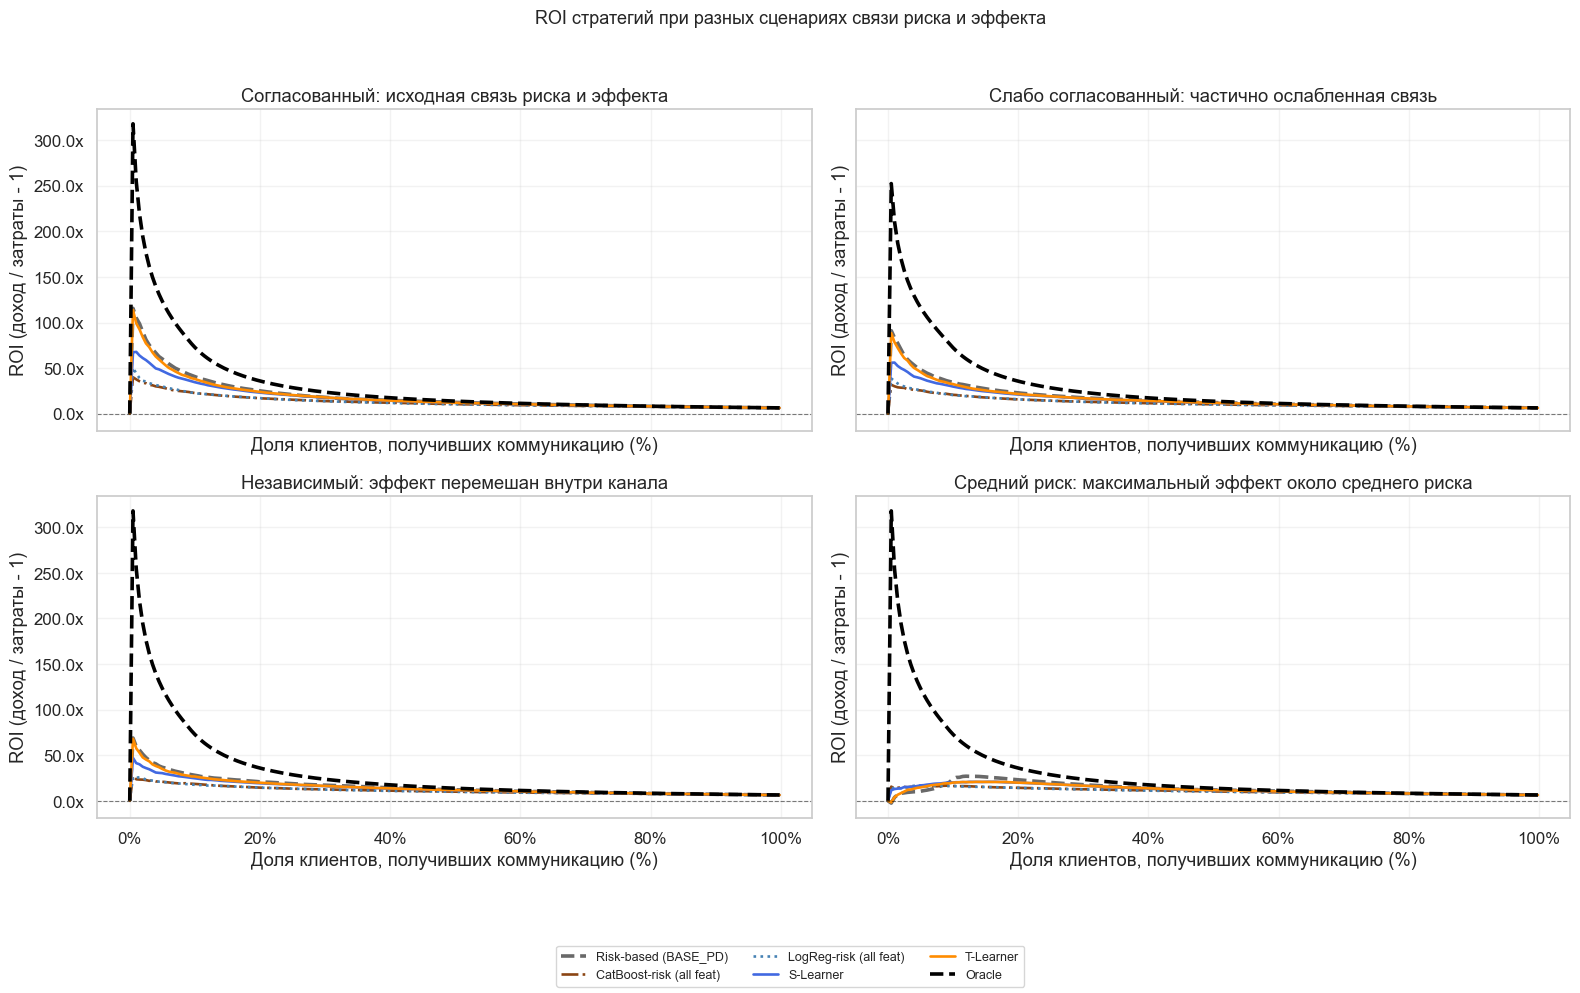

max ROI  охват при max ROI
Сценарий            Стратегия                                           
Независимый         CatBoost-risk (all feat)  27.1400             0.5000
                    LogReg-risk (all feat)    26.1100             0.5000
                    Oracle                   317.9400             0.5000
                    Risk-based (BASE_PD)      68.8700             0.5000
                    S-Learner                 47.0000             0.5000
                    T-Learner                 68.0600             0.5000
Слабо согласованный CatBoost-risk (all feat)  31.6700             0.5000
                    LogReg-risk (all feat)    38.5900             0.5000
                    Oracle                   252.3800             0.5000
                    Risk-based (BASE_PD)      91.0500             0.5000
                    S-Learner                 56.0500             1.0000
                    T-Learner                 88.3200             0.5000
Согласованный       CatBoost-risk (all feat)  39.9600             0.5000
                    LogReg-risk (all feat)    50.4900             0.5000
                    Oracle                   317.9400             0.5000
                    Risk-based (BASE_PD)     115.5700             0.5000
                    S-Learner                 67.7900             1.0000
                    T-Learner                113.7200             0.5000
Средний риск        CatBoost-risk (all feat)  16.5600             9.0000
                    LogReg-risk (all feat)    16.6800             5.0000
                    Oracle                   317.9400             0.5000
                    Risk-based (BASE_PD)      26.9500            12.0000
                    S-Learner                 20.8900            16.5000
                    T-Learner                 20.7700            13.5000

Где кривая пересекает 0 - точка безубыточности кампании.
Чем выше пик кривой - тем выгоднее стратегия при оптимальном бюджете.


In [9]:
def compute_roi_curve(df, score, n_points=200, cost_per_contact=COST_ANY_CONTACT,
                      benefit_col='prevented_default_prob'):
    """Кривая ROI при увеличении охвата."""
    df_sorted = df.assign(score=score).sort_values('score', ascending=False).reset_index(drop=True)
    n = len(df_sorted)
    step = max(1, n // n_points)

    fracs, roi_vals = [0.0], [0.0]
    for k in range(step, n + 1, step):
        top_k = df_sorted.iloc[:k]
        prevented = top_k[benefit_col].sum()
        econ_value = prevented * LOSS_GIVEN_DEFAULT
        cost = k * cost_per_contact
        roi = (econ_value - cost) / cost if cost > 0 else 0
        fracs.append(k / n)
        roi_vals.append(roi)
    return np.array(fracs), np.array(roi_vals)


roi_plot_strategies = [
    'Risk-based (BASE_PD)',
    'CatBoost-risk (all feat)',
    'LogReg-risk (all feat)',
    'S-Learner',
    'T-Learner',
    'Oracle',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

roi_summary_rows = []
for ax, sc_name in zip(axes, scenario_generators.keys()):
    df_sc = make_scenario_frame(df_test, sc_name)
    sc_scores = scenario_strategy_scores(df_sc, sc_name)

    for name in roi_plot_strategies:
        fracs, roi_vals = compute_roi_curve(df_sc, sc_scores[name])
        best_idx = int(np.nanargmax(roi_vals))
        roi_summary_rows.append({
            'Сценарий': _scenario_labels[sc_name],
            'Стратегия': name,
            'max ROI': roi_vals[best_idx],
            'охват при max ROI': fracs[best_idx],
        })

        lw = 2.6 if name in ('Oracle', 'Risk-based (BASE_PD)') else 1.9
        ax.plot(fracs * 100, roi_vals,
                label=name,
                color=strategy_colors[name],
                linestyle=strategy_styles[name],
                linewidth=lw)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f"{_scenario_labels[sc_name]}: {_scenario_explain[sc_name]}")
    ax.set_xlabel('Доля клиентов, получивших коммуникацию (%)')
    ax.set_ylabel('ROI (доход / затраты - 1)')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9)
plt.suptitle('ROI стратегий при разных сценариях связи риска и эффекта', fontsize=13)
plt.tight_layout(rect=[0, 0.10, 1, 0.96])
plt.show()

roi_summary_df = pd.DataFrame(roi_summary_rows)
roi_summary_df['охват при max ROI'] = (roi_summary_df['охват при max ROI'] * 100).round(1)
display(roi_summary_df.pivot_table(
    index=['Сценарий', 'Стратегия'],
    values=['max ROI', 'охват при max ROI'],
    aggfunc='first',
).round({'max ROI': 2, 'охват при max ROI': 1}))

print('Где кривая пересекает 0 - точка безубыточности кампании.')
print('Чем выше пик кривой - тем выгоднее стратегия при оптимальном бюджете.')

<h3 id="policy-roi-summary">Выводы по разделу 6</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по ROI в сценариях.</b>

<p><b>1. По ROI S/T-Learner дают явное преимущество над CatBoost/LogReg-risk.</b></p>

В `aligned` max ROI у T-Learner равен примерно 113.7, у S-Learner — 67.8, тогда как CatBoost-risk дает около 40.0, а LogReg-risk — 50.5. В `orthogonal` T-Learner достигает 68.1 против 27.1 у CatBoost и 26.1 у LogReg. В `mid_risk` uplift тоже выше: S/T-Learner около 20.8–20.9 против 16.6–16.7 у CatBoost/LogReg.

Это важный результат: uplift не выигрывает у идеализированного `BASE_PD`, но дает более высокий ROI, чем реалистичные risk-модели.

<p><b>2. `BASE_PD` остается сильным ориентиром, но не production-конкурентом.</b></p>

Max ROI у `BASE_PD` высок: 115.6 в `aligned`, 91.1 в `weakly_aligned`, 68.9 в `orthogonal`, 27.0 в `mid_risk`. T-Learner почти догоняет его в `aligned` и `orthogonal`, но обычно не превосходит. Это показывает силу связи риска и эффекта в синтетическом стенде, а не слабость uplift как подхода.

<p><b>3. Оптимальный охват часто находится в очень верхней части рейтинга.</b></p>

Для Oracle, `BASE_PD`, CatBoost/LogReg и T-Learner в большинстве сценариев максимум ROI достигается при охвате около 0.5%. Это означает, что самая высокая отдача концентрируется в узком верхнем сегменте клиентов. В `mid_risk` оптимальный охват смещается шире: около 12% для `BASE_PD`, 13.5% для T-Learner и 16.5% для S-Learner. Это согласуется с идеей, что изменяемый сегмент не всегда находится в самом верху risk-рейтинга.

<p><b>4. ROI помогает объяснить, почему uplift не внедряется автоматически.</b></p>

Если сравнивать с `BASE_PD`, uplift не выглядит очевидным победителем. Но если сравнивать с CatBoost/LogReg, uplift дает существенный ROI-прирост. Значит, практический вопрос не «лучше ли uplift идеального знания риска», а «лучше ли uplift того скоринга, который банк реально способен построить и поддерживать».

<p><b>5. Практический вывод.</b></p>

ROI-сравнение нужно встроить в процесс внедрения: сначала strong risk baseline, затем uplift-модель, затем проверка на фиксированных охватах, сценариях и каналах. Если uplift стабильно улучшает ROI относительно CatBoost/LogReg-risk, его сложность становится экономически обоснованной.

<b>Итог.</b> ROI-сценарии показывают применимость uplift более убедительно: S/T-Learner не превосходят синтетический `BASE_PD`, но дают заметный финансовый выигрыш относительно реалистичных risk-моделей.

</div>

In [10]:
# Multi-treatment policy на основе T-Learner (per-channel uplift)
# T-Learner у нас даёт uplift по каждому каналу отдельно

# Ожидаемый чистый эффект = (-uplift) * LGD - cost
# Нормализуем LGD к числу клиентов для удобства: используем relative units

def compute_optimal_channel(df, uplift_cols, costs_dict, lgd=LOSS_GIVEN_DEFAULT):
    # Вычисляет оптимальный канал для каждого клиента.
    # uplift_cols: словарь {channel_name: column_name_in_df}
    # costs_dict:  словарь {channel_name: cost}

    net_values = {'control': pd.Series(np.zeros(len(df)), index=df.index)}

    for ch, col in uplift_cols.items():
        # net_value = -uplift * LGD - cost
        # (отрицательный uplift = снижение PD = хорошо, поэтому минус даёт положительное)
        net_values[ch] = -df[col] * lgd - costs_dict[ch]

    net_df = pd.DataFrame(net_values)
    # Оптимальный канал - с наибольшим net_value
    optimal_channel = net_df.idxmax(axis=1)
    optimal_net_value = net_df.max(axis=1)

    return optimal_channel, optimal_net_value, net_df


# Per-channel uplift S-Learner
uplift_cols_s = {
    'sms':          'uplift_s_sms',
    'robot_call':   'uplift_s_robot',
    'operator_call':'uplift_s_operator',
}
costs_per_client = {
    'sms':          COMM_COSTS['sms'],
    'robot_call':   COMM_COSTS['robot_call'],
    'operator_call':COMM_COSTS['operator_call'],
}

opt_channel_s, opt_value_s, net_df_s = compute_optimal_channel(
    df_test, uplift_cols_s, costs_per_client
)

print('Оптимальное распределение каналов (S-Learner policy):')
ch_dist = opt_channel_s.value_counts(normalize=True).mul(100).round(1)
print(ch_dist.astype(str) + '%')

print(f'\nОжидаемый суммарный чистый эффект: {opt_value_s.sum()/1_000_000:.2f} млн руб.')
print(f'Ожидаемый чистый эффект на клиента: {opt_value_s.mean():.0f} руб.')


Оптимальное распределение каналов (S-Learner policy):
robot_call    99.0%
sms            1.0%
control        0.0%
Name: proportion, dtype: object

Ожидаемый суммарный чистый эффект: 492.44 млн руб.
Ожидаемый чистый эффект на клиента: 8007 руб.


In [11]:
# Аналогично для T-Learner
uplift_cols_t = {
    'sms':          'uplift_t_sms',
    'robot_call':   'uplift_t_robot',
    'operator_call':'uplift_t_operator',
}

opt_channel_t, opt_value_t, net_df_t = compute_optimal_channel(
    df_test, uplift_cols_t, costs_per_client
)

print('Оптимальное распределение каналов (T-Learner policy):')
print(opt_channel_t.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Сравниваем с истинным оптимальным распределением (oracle)
print('\nИстинное оптимальное распределение каналов (Oracle, ORACLE_COMMUNICATION):')
if 'ORACLE_COMMUNICATION' in pd.read_csv('data/processed/uplift-dataset.csv').columns:
    # Загрузим из полного датасета
    df_full = pd.read_csv('data/processed/uplift-dataset.csv')
    n_test = len(df_test)
    oot_size = int(len(df_full) * 0.2)
    test_start = oot_size + int((len(df_full) - oot_size) * 0.75)
    oracle_comm = df_full.iloc[test_start:test_start + n_test]['ORACLE_COMMUNICATION'].reset_index(drop=True)
    print(oracle_comm.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
else:
    print('  (ORACLE_COMMUNICATION недоступна в uplift_scores.csv)')


Оптимальное распределение каналов (T-Learner policy):
sms           97.5%
robot_call     2.4%
control        0.1%
Name: proportion, dtype: object

Истинное оптимальное распределение каналов (Oracle, ORACLE_COMMUNICATION):


ORACLE_COMMUNICATION
robot_call       38.5%
operator_call    38.2%
sms              21.2%
control           2.1%
Name: proportion, dtype: object


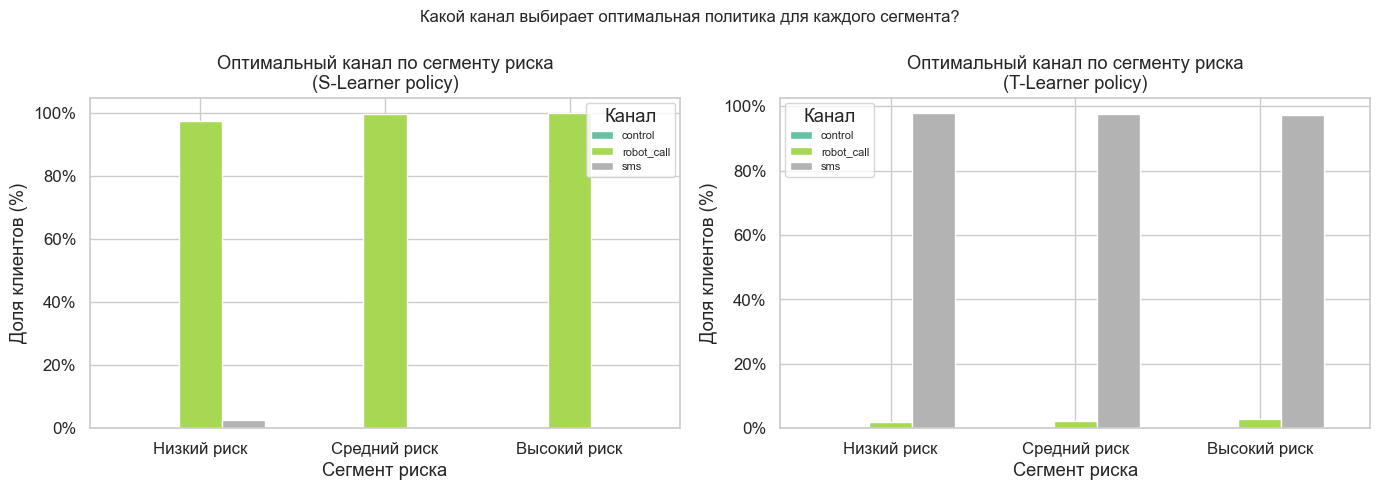

Интерпретация: соответствует ли распределение каналов интуиции?
  high_risk -> operator_call (дорого, но эффективно при высоком BASE_PD)
  low_risk  -> sms (дёшево, при маленьком BASE_PD operator не окупается)


In [12]:
# Визуализация: распределение каналов по сегментам риска
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, opt_ch) in zip(axes, [('S-Learner', opt_channel_s), ('T-Learner', opt_channel_t)]):
    ch_by_seg = pd.crosstab(df_test['RISK_SEGMENT'], opt_ch, normalize='index') * 100
    # Порядок сегментов
    seg_order = ['low_risk', 'medium_risk', 'high_risk']
    ch_by_seg = ch_by_seg.reindex(seg_order, fill_value=0)

    ch_by_seg.plot(kind='bar', ax=ax, width=0.7, colormap='Set2')
    ax.set_title(f'Оптимальный канал по сегменту риска\n({name} policy)')
    ax.set_xlabel('Сегмент риска')
    ax.set_ylabel('Доля клиентов (%)')
    ax.legend(title='Канал', fontsize=8)
    ax.set_xticklabels(['Низкий риск', 'Средний риск', 'Высокий риск'], rotation=0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('Какой канал выбирает оптимальная политика для каждого сегмента?', fontsize=12)
plt.tight_layout()
plt.show()

print('Интерпретация: соответствует ли распределение каналов интуиции?')
print('  high_risk -> operator_call (дорого, но эффективно при высоком BASE_PD)')
print('  low_risk  -> sms (дёшево, при маленьком BASE_PD operator не окупается)')


<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Практический смысл multi-treatment.</b> Если модель почти всегда выбирает один канал, это сигнал не только о модели, но и о данных: альтернативные каналы могут быть плохо покрыты исторической политикой.

</div>


<h3 id="policy-multitreatment-summary">Выводы по разделу 7</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по multi-treatment policy.</b>

<p><b>1. Выбор канала оказался сложнее, чем выбор клиента.</b></p>

S-Learner почти всегда выбирает `robot_call` — около 99% клиентов. T-Learner, наоборот, почти всегда выбирает `sms` — около 97.5% клиентов. Такое поведение говорит, что модели нашли устойчивый общий паттерн, но не восстановили разнообразную структуру оптимального назначения каналов.

<p><b>2. Oracle показывает гораздо более разнообразную политику.</b></p>

Истинная oracle-политика распределяет клиентов между каналами иначе: `robot_call` около 38.5%, `operator_call` около 38.2%, `sms` около 21.2%, `control` около 2.1%. Значит, в синтетическом ground truth оптимальная коммуникация не сводится к одному универсальному каналу.

<p><b>3. Это важный барьер для внедрения uplift в финтехе.</b></p>

Даже если uplift-модель лучше ранжирует клиентов, ей может быть трудно корректно выбрать канал. Для multi-treatment задачи нужны наблюдения по альтернативным каналам, достаточный overlap и controlled exploration. Без этого модель может выучить слишком грубую политику: например, почти всегда выбирать один дешевый или один средний канал.

<p><b>4. Практический вывод.</b></p>

На текущем этапе S/T-Learner полезны прежде всего как политики отбора клиентов. Для полноценной channel-optimization их нужно дополнять экспериментальным дизайном: тестировать каналы внутри risk-сегментов, сохранять контрольные группы и отдельно валидировать стоимость/эффект каждого канала.

<b>Итог.</b> Multi-treatment блок показывает еще одну причину, почему uplift редко внедряется «из коробки»: выбрать клиента проще, чем надежно выбрать оптимальный канал воздействия.

</div>

<h2 id="policy-segments">8. Сегментация клиентов: Persuadables, Sure Things, Sleeping Dogs, Lost Causes</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Сегментация нужна, чтобы объяснить результат не только через графики и метрики, но и через типы клиентской реакции.

Persuadables - клиенты, которым коммуникация действительно помогает. Sure Things заплатили бы и без контакта. Lost Causes не реагируют на коммуникацию. Sleeping Dogs могут отреагировать отрицательно. Эта логика показывает, почему высокий риск сам по себе не равен высокой полезности звонка.

</div>


In [13]:
# Пороговое значение для классификации эффекта как 'значимого'
UPLIFT_THRESHOLD = df_test['TRUE_UPLIFT'].std() * 0.5
print(f'Порог для Persuadable/Sleeping Dog: {UPLIFT_THRESHOLD:.5f}')

# Сегментация по TRUE_UPLIFT
df_test_seg = df_test.copy()

conditions = [
    df_test_seg['TRUE_UPLIFT'] < -UPLIFT_THRESHOLD,                         # Persuadable
    df_test_seg['TRUE_UPLIFT'] >  UPLIFT_THRESHOLD,                         # Sleeping Dog
    (df_test_seg['TRUE_UPLIFT'].abs() <= UPLIFT_THRESHOLD) &
    (df_test_seg['BASE_PD'] < df_test_seg['BASE_PD'].median()),              # Sure Thing
]
labels = ['Persuadable', 'Sleeping Dog', 'Sure Thing']
df_test_seg['segment'] = np.select(conditions, labels, default='Lost Cause')

print('\nРаспределение клиентов по сегментам (test):')
print(df_test_seg['segment'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print('\nСредний TRUE_UPLIFT по сегментам:')
print(df_test_seg.groupby('segment')['TRUE_UPLIFT'].mean().round(5))


Порог для Persuadable/Sleeping Dog: 0.00556

Распределение клиентов по сегментам (test):
segment
Sure Thing      48.3%
Lost Cause      43.4%
Persuadable      8.1%
Sleeping Dog     0.1%
Name: proportion, dtype: object

Средний TRUE_UPLIFT по сегментам:
segment
Lost Cause     -0.0000
Persuadable    -0.0298
Sleeping Dog    0.0113
Sure Thing     -0.0000
Name: TRUE_UPLIFT, dtype: float64


In [14]:
# Насколько хорошо каждая модель идентифицирует Persuadables?
# Оцениваем: среди top-K% по скору - какая доля реальных Persuadables?

persuadable_mask = (df_test_seg['segment'] == 'Persuadable').values
sleeping_dog_mask = (df_test_seg['segment'] == 'Sleeping Dog').values

print('Качество идентификации Persuadables (top-20% по скору):')
print(f'{'Стратегия':<30} {'Persuadables, %':>18} {'Sleeping Dogs, %':>18}')
print('-' * 68)

k20 = int(len(df_test) * 0.20)
for name, score in strategies.items():
    if name == 'Никого не контактировать':
        continue
    top_k_idx = np.argsort(-score)[:k20]
    pct_persuadable  = persuadable_mask[top_k_idx].mean() * 100
    pct_sleeping_dog = sleeping_dog_mask[top_k_idx].mean() * 100
    print(f'{name:<30} {pct_persuadable:>17.1f}% {pct_sleeping_dog:>17.1f}%')

print(f'\nВ популяции: Persuadables={persuadable_mask.mean()*100:.1f}%, '
      f'Sleeping Dogs={sleeping_dog_mask.mean()*100:.1f}%')


Качество идентификации Persuadables (top-20% по скору):
Стратегия                         Persuadables, %   Sleeping Dogs, %
--------------------------------------------------------------------
Случайный выбор                              7.8%               0.1%
Risk-based (BASE_PD)                        20.3%               0.2%


CatBoost-risk (all feat)                    15.0%               0.2%
LogReg-risk (all feat)                      14.9%               0.1%
S-Learner                                   19.1%               0.2%
T-Learner                                   19.5%               0.2%
X-Learner                                    9.2%               0.1%
DR-Learner                                  10.2%               0.2%
Oracle                                      40.7%               0.0%

В популяции: Persuadables=8.1%, Sleeping Dogs=0.1%


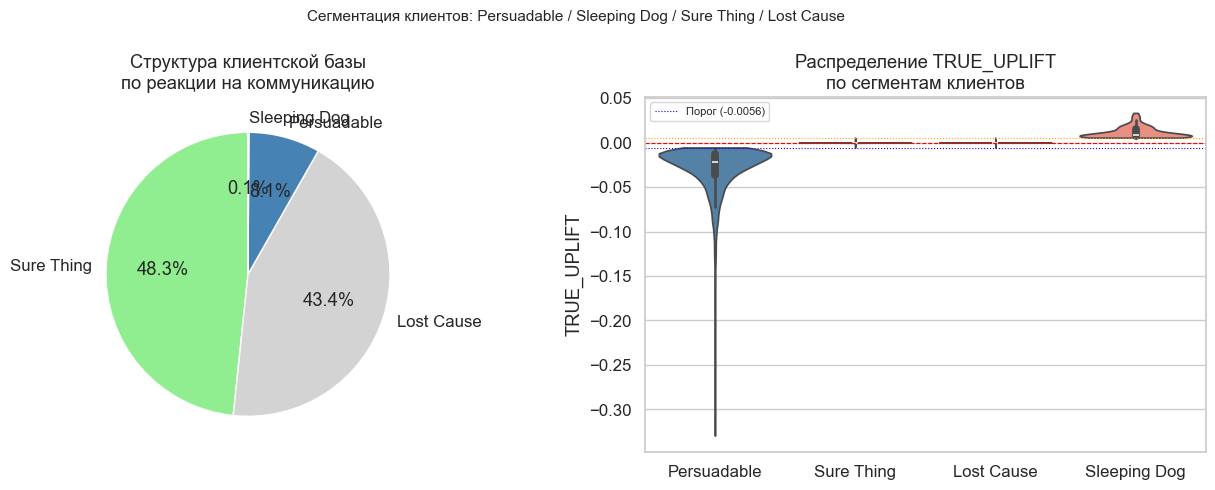

In [15]:
# Визуализация: pie chart сегментов + violin plot uplift по сегментам
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
seg_counts = df_test_seg['segment'].value_counts()
colors_seg = {'Persuadable': 'steelblue', 'Sure Thing': 'lightgreen',
              'Sleeping Dog': 'salmon', 'Lost Cause': 'lightgray'}
axes[0].pie(seg_counts.values, labels=seg_counts.index,
            colors=[colors_seg[s] for s in seg_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Структура клиентской базы\nпо реакции на коммуникацию')

# Violin plot TRUE_UPLIFT по сегментам
seg_order = ['Persuadable', 'Sure Thing', 'Lost Cause', 'Sleeping Dog']
df_violin = df_test_seg[df_test_seg['segment'].isin(seg_order)]
sns.violinplot(data=df_violin, x='segment', y='TRUE_UPLIFT',
               order=seg_order, palette=colors_seg,
               ax=axes[1], inner='box', cut=0)
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].axhline(-UPLIFT_THRESHOLD, color='blue', linewidth=0.8, linestyle=':',
                label=f'Порог ({-UPLIFT_THRESHOLD:.4f})')
axes[1].axhline(UPLIFT_THRESHOLD, color='orange', linewidth=0.8, linestyle=':')
axes[1].set_title('Распределение TRUE_UPLIFT\nпо сегментам клиентов')
axes[1].set_xlabel('')
axes[1].set_ylabel('TRUE_UPLIFT')
axes[1].legend(fontsize=8)

plt.suptitle('Сегментация клиентов: Persuadable / Sleeping Dog / Sure Thing / Lost Cause',
             fontsize=11)
plt.tight_layout()
plt.show()


<div class="alert alert-warning" style="background-color:#fff8e6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Кандидат на уплотнение вывода.</b> Сегментационная визуализация хороша для объяснения, но ее можно сжать до долей сегментов и top-20% концентрации Persuadables.

</div>


<h3 id="policy-segments-summary">Выводы по разделу 8</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по сегментации клиентов.</b>

<p><b>1. Persuadables — небольшой, но ценный сегмент.</b></p>

В test-выборке Persuadables составляют только около 8.1% клиентов. Поэтому задача коммуникационной политики — не просто найти рискованных клиентов, а сконцентрировать именно тех, у кого контакт реально снижает вероятность дефолта.

<p><b>2. S/T-Learner лучше обученных risk-моделей находят Persuadables.</b></p>

В top-20% по скору CatBoost-risk и LogReg-risk находят около 15.0% и 14.9% Persuadables. S-Learner и T-Learner дают 19.1% и 19.5%, то есть заметно лучше реалистичных risk-моделей. `BASE_PD` остается чуть выше — 20.3%, но он снова выступает как синтетический риск-ориентир.

<p><b>3. До Oracle остается большой разрыв.</b></p>

Oracle концентрирует 40.7% Persuadables в top-20%, то есть примерно вдвое больше, чем лучшие доступные стратегии. Это показывает, что потенциал улучшения остается, но его нельзя извлечь только обычным risk-score или текущими uplift-моделями.

<p><b>4. Sleeping Dogs почти не представлены.</b></p>

Sleeping Dogs составляют около 0.1% популяции, поэтому в этом синтетическом стенде основной практический риск связан не столько с массовым вредом коммуникации, сколько с неэффективным расходованием контактов на Sure Things и Lost Causes.

<b>Итог.</b> Сегментация подтверждает практический смысл uplift: относительно CatBoost/LogReg-risk S/T-Learner лучше концентрируют клиентов, которым коммуникация действительно помогает.

</div>

<h2 id="policy-bootstrap">9. Bootstrap доверительные интервалы</h2>

<div class="alert alert-info" style="max-width: 99%; padding:10px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

Бизнес-оценка не должна опираться только на одну точку. Даже на одной и той же тестовой выборке результат может колебаться из-за состава клиентов.

Bootstrap используется как проверка устойчивости: мы многократно пересобираем выборку и смотрим, насколько сильно меняются предотвращенные дефолты и чистый эффект.

</div>


In [16]:
N_BOOTSTRAP = 500
K_FRAC      = 0.20   # фиксированный охват для bootstrap

rng_boot = np.random.RandomState(RANDOM_SEED)

bootstrap_results = {name: [] for name in strategies if name != 'Никого не контактировать'}

print(f'Bootstrap ({N_BOOTSTRAP} итераций, охват={K_FRAC:.0%})...')
for b in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(df_test), size=len(df_test), replace=True)
    df_b = df_test.iloc[idx].reset_index(drop=True)

    for name, score in strategies.items():
        if name == 'Никого не контактировать':
            continue
        score_b = score[idx]
        m = policy_at_k(df_b, score_b, K_FRAC)
        bootstrap_results[name].append(m['prevented_pd'])

    if (b + 1) % 100 == 0:
        print(f'  {b+1}/{N_BOOTSTRAP}', end='\r')

print('\nBootstrap завершён.')
print(f'\n95% CI снижения PD при охвате {K_FRAC:.0%}:')
print(f'{'Стратегия':<30} {'Среднее':>10} {'CI 2.5%':>10} {'CI 97.5%':>10}')
print('-' * 65)
boot_summary = {}
for name, vals in bootstrap_results.items():
    arr = np.array(vals)
    boot_summary[name] = (arr.mean(), np.percentile(arr, 2.5), np.percentile(arr, 97.5))
    m, lo, hi = boot_summary[name]
    print(f'{name:<30} {m:>10.4f} {lo:>10.4f} {hi:>10.4f}')


Bootstrap (500 итераций, охват=20%)...


  500/500
Bootstrap завершён.

95% CI снижения PD при охвате 20%:
Стратегия                         Среднее    CI 2.5%   CI 97.5%
-----------------------------------------------------------------
Случайный выбор                   29.0174    26.7963    31.3110
Risk-based (BASE_PD)             106.3294   101.6284   110.7503
CatBoost-risk (all feat)          73.6374    70.1029    77.5739
LogReg-risk (all feat)            73.5779    69.8884    77.3014
S-Learner                         98.6157    94.1737   103.0109
T-Learner                        101.7086    97.1360   106.2540
X-Learner                         42.1638    38.7491    45.5109
DR-Learner                        45.7623    43.0702    49.0209
Oracle                           151.3812   146.6740   156.5722


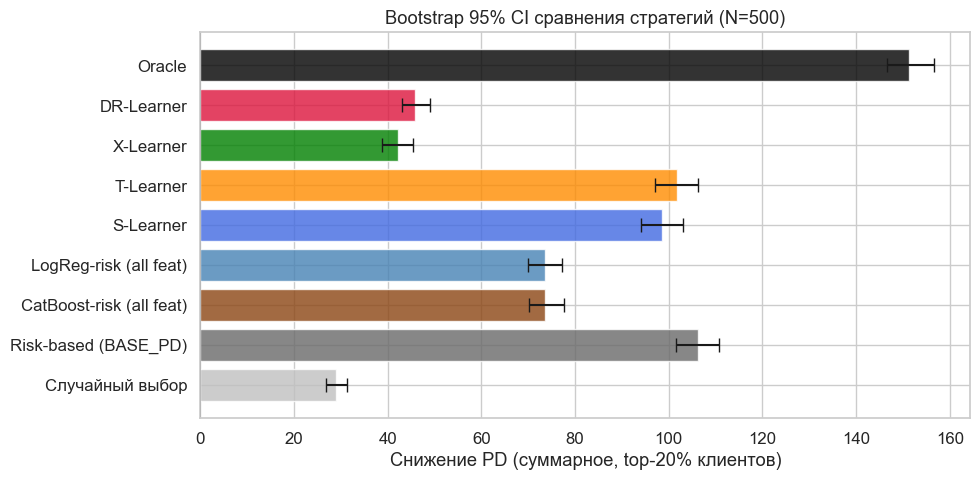


Если CI двух стратегий не пересекаются - разница статистически значима (p < 0.05).


In [17]:
# Визуализация Bootstrap CI
fig, ax = plt.subplots(figsize=(10, 5))

names = list(boot_summary.keys())
means = [boot_summary[n][0] for n in names]
lows  = [boot_summary[n][1] for n in names]
highs = [boot_summary[n][2] for n in names]
errors_lo = [m - lo for m, lo in zip(means, lows)]
errors_hi = [hi - m for m, hi in zip(means, highs)]

y_pos = range(len(names))
colors = [strategy_colors[n] for n in names]

ax.barh(y_pos, means, xerr=[errors_lo, errors_hi],
        color=colors, alpha=0.8, capsize=5, error_kw={'elinewidth': 1.5})
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('Снижение PD (суммарное, top-20% клиентов)')
ax.set_title(f'Bootstrap 95% CI сравнения стратегий (N={N_BOOTSTRAP})')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print()
print('Если CI двух стратегий не пересекаются - разница статистически значима (p < 0.05).')


<div class="alert alert-secondary" style="background-color:#f8f8fb; max-width: 99%; padding:10px; border-width:2px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Как читать bootstrap.</b> Здесь важны не только средние значения, но и пересечение интервалов. Если интервалы двух стратегий сильно перекрываются, бизнес-разницу стоит трактовать осторожно.

</div>


<h3 id="policy-bootstrap-summary">Выводы по разделу 9</h3>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Вывод по bootstrap-интервалам.</b>

<p><b>1. Преимущество S/T-Learner над CatBoost/LogReg-risk устойчиво.</b></p>

При охвате 20% CatBoost-risk дает среднее снижение PD 73.64 с 95% CI [70.10; 77.57], LogReg-risk — 73.58 с CI [69.89; 77.30]. S-Learner дает 98.62 с CI [94.17; 103.01], T-Learner — 101.71 с CI [97.14; 106.25]. Интервалы uplift-моделей не пересекаются с интервалами CatBoost/LogReg, поэтому преимущество S/T-Learner над реалистичными risk-моделями выглядит статистически устойчивым.

<p><b>2. `BASE_PD` остается близким к T-Learner, но его интерпретация ограничена.</b></p>

`BASE_PD` дает 106.33 с CI [101.63; 110.75]. Его интервал пересекается с T-Learner, что подтверждает силу идеализированного риск-ориентира. Но это не отменяет практического вывода: T-Learner значительно превосходит обученные CatBoost/LogReg-risk модели.

<p><b>3. S-Learner и T-Learner находятся в близкой зоне.</b></p>

Интервалы S-Learner и T-Learner пересекаются, поэтому разницу между ними в бизнес-метрике нужно трактовать осторожно. T-Learner немного выше по среднему, но для внедрения важнее общий вывод: оба uplift-подхода устойчиво лучше реалистичных risk-baseline.

<p><b>4. X-Learner и DR-Learner остаются слабыми.</b></p>

X-Learner и DR-Learner дают около 42.16 и 45.76 снижения PD, что заметно ниже CatBoost/LogReg и намного ниже S/T-Learner. Это подтверждает вывод предыдущего ноутбука: более сложная causal-архитектура не гарантирует бизнес-выигрыш.

<b>Итог.</b> Bootstrap усиливает центральный вывод: uplift-модели S/T дают не случайный, а устойчивый прирост относительно реалистичных risk-моделей, хотя синтетический `BASE_PD` остается очень сильным ориентиром.

</div>

<h2 id="policy-conclusions">10. Итоговые выводы и практические рекомендации</h2>

<div class="alert alert-success" style="background-color:#e6ffe6; max-width: 99%; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">

<b>Итоговый вывод ноутбука.</b> Финансовая оценка показывает, что применимость uplift в финтехе нужно обсуждать не в формате «uplift всегда лучше risk-score», а через сравнение с несколькими уровнями risk baseline.

<p><b>1. `BASE_PD` объясняет, почему uplift сложно обосновать.</b></p>

Синтетический `BASE_PD` часто остается сильнее S/T-Learner. Это показывает, что если риск и эффект коммуникации связаны структурно, risk-based политика может выглядеть почти оптимальной. Именно поэтому uplift-подходы не становятся очевидным стандартом в финтехе.

<p><b>2. Сравнение с CatBoost/LogReg дает практический аргумент в пользу uplift.</b></p>

Относительно реалистичных risk-моделей S-Learner и T-Learner дают заметный прирост: выше процент от Oracle при фиксированном охвате, выше ROI в сценариях, лучше концентрация Persuadables и устойчивое преимущество по bootstrap-интервалам. Это показывает, что uplift может добавлять бизнес-ценность сверх классического кредитного скоринга.

<p><b>3. Uplift не должен внедряться как замена скорингу.</b></p>

Практическая роль uplift — дополнительный слой принятия решений: кого контактировать, кого не трогать, и какой канал выбрать. Скоринг риска остается важной частью системы, но он отвечает на другой вопрос: кто рискованнее, а не чье поведение изменится от коммуникации.

<p><b>4. Главные барьеры внедрения.</b></p>

Результаты ноутбука показывают типичные препятствия: сильные risk-baseline, слабый treatment effect, неслучайное назначение коммуникаций, слабый overlap, несбалансированная история по каналам и сложность доказательства ROI перед бизнесом.

<p><b>5. Что нужно для практического применения uplift.</b></p>

Для внедрения нужны контрольные группы внутри risk-сегментов, регулярное сравнение с CatBoost/LogReg-risk, мониторинг ROI на фиксированных охватах, накопление данных по каждому каналу и отдельная проверка multi-treatment политики.

<b>Практический смысл для диссертации.</b> Uplift-подход применим не потому, что всегда побеждает риск-скоринг, а потому что при правильном дизайне данных способен дать дополнительный финансовый эффект относительно реалистичных risk-моделей и лучше находить клиентов, чье поведение действительно меняется от коммуникации.

</div>